In [ ]:
import os
os.chdir("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/src/notebooks")

In [3]:
from ipyhead import *

In [10]:
# dataroot = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/data/davis_3d"
# dataroot = "/home/chenyu/project/optimize-gaussian/data/davis/train"
dataroot = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/data/davis_vipe_output"
def load_data(dataroot, artifact_name:str, max_frames:int=20):
    
    depths = read_depth_artifacts(os.path.join(dataroot,  "depth", f"{artifact_name}.zip"))
    rgbs = read_rgb_artifacts(os.path.join(dataroot, "rgb", f"{artifact_name}.mp4"))
    poses = read_pose_artifacts(os.path.join(dataroot, "pose", f"{artifact_name}.npz"))
    extrinsics = closed_form_inverse_se3(poses)
    intrinsics = read_intrinsics_artifacts(os.path.join(dataroot, "intrinsics", f"{artifact_name}.npz"))
    fwd_flows, bwd_flows, fwd_weights, bwd_weights = read_flow_artifacts(os.path.join(dataroot, "flow", f"{artifact_name}.zip"))
    cam_points = depth_map_to_cam_coords(depths, intrinsics)
    world_points = depth_map_to_world_coords(depths, intrinsics, extrinsics)
    max_frames = min(max_frames, len(depths))
    return {
        "intrinsics": intrinsics[:max_frames],
        "extrinsics": extrinsics[:max_frames],
        "rgb": rgbs[:max_frames],
        "fwd_flows": fwd_flows[:max_frames],
        "fwd_weights": fwd_weights[:max_frames],
        "bwd_weights": bwd_weights[:max_frames],
        "bwd_flows": bwd_flows[:max_frames],
        "depths": depths[:max_frames],
        "cam_points": cam_points[:max_frames],
        "world_points": world_points[:max_frames],
    }



In [12]:
data = load_data(dataroot, "train", 100)

In [9]:
for key in data:
    print(f"{key}: {data[key].shape}")

intrinsics: torch.Size([75, 3, 3])
extrinsics: torch.Size([75, 4, 4])
rgb: torch.Size([75, 480, 854, 3])
fwd_flows: torch.Size([75, 480, 854, 2])
fwd_weights: torch.Size([75, 480, 854])
bwd_weights: torch.Size([75, 480, 854])
bwd_flows: torch.Size([75, 480, 854, 2])
depths: torch.Size([75, 480, 854])
cam_points: torch.Size([75, 480, 854, 3])
world_points: torch.Size([75, 480, 854, 3])
dyn_masks: torch.Size([75, 480, 854])


In [7]:
data["fwd_flows"].shape

torch.Size([12, 540, 960, 2])

In [22]:
dyn_masks = read_rgb_artifacts("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/temp.mp4")
velocity = read_rgb_artifacts("/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/download.mp4")
dyn_masks[:, 400:, 400:] = 0

In [ ]:
for ind in [0, 2, 6, 10]:
    Image.fromarray(flow_to_image(data["fwd_flows"][ind].numpy())).save(f"{ind:05d}_flow.png")
    Image.fromarray((data["rgb"][ind].numpy() * 255).astype(np.uint8)).save(f"{ind:05d}_rgb.png")
    Image.fromarray((data["depths"][ind].numpy() / data["depths"][ind].numpy().max() * 255).astype(np.uint8)).save(f"{ind:05d}_depth.png")
    Image.fromarray((dyn_masks[ind].numpy() * 255).astype(np.uint8)).save(f"{ind:05d}_dynmask.png")
    Image.fromarray((velocity[ind].numpy() * 255).astype(np.uint8)).save(f"{ind:05d}_velocity.png")    

In [ ]:
for i, depth in enumerate(data["depths"]):
    np.save(f"/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/dependencies/SpaTracker/assets/train/")

In [ ]:



fwd_mask, bwd_mask = compute_flow_masks(
    data["fwd_flows"][1:-1],
    data["bwd_flows"][1:-1],
    0.5,
    0.5
)
# # 
# masks = fwd_mask & bwd_mask
# masked_rgb = dyn_masks.unsqueeze(-1) * data["rgb"][1:-1]
masked_rgb = (fwd_mask.unsqueeze(-1) & bwd_mask.unsqueeze(-1)) * data["rgb"][1:-1]

# masked_rgb = stat_masks.unsqueeze(-1) * data["rgb"][1:-1]
masked_rgb = rearrange(masked_rgb, "s h w c -> 1 s c h w")
visualize_tensor_video(masked_rgb, fps=8)
# print(masks.shape)
# Image.fromarray((masks[0, ..., None].cpu().numpy() * data["rgb"][1].cpu().numpy() * 255.0).astype(np.uint8))


/n/home04/chenyuwu/.conda/envs/optim/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


In [14]:
dyn_masks, stat_masks = compute_dynamic_masks(
    data["fwd_flows"],
    data["bwd_flows"],
    data["world_points"],
    data["intrinsics"],
    data["extrinsics"],
    alpha=0.1,
    dynamic_thres=2.0,
    static_thres=1.0
    # data["depths"]
)
dyn_masks = dyn_masks[0]
stat_masks = stat_masks[0]
masks = dyn_masks

In [ ]:
points = []
rgbs = []
# export dynamic part
for i in range(1, len(data["rgb"])-1, 2):
    points.append(
        data["world_points"][i][masks[i - 1]].reshape(-1, 3),
    )
    rgbs.append(
        data["rgb"][i][masks[i - 1]].reshape(-1, 3),
    )

export_pointcloud(
    torch.cat(points, dim=0),
    torch.cat(rgbs, dim=0),
    "misc/dynamic.ply"
)

In [10]:
points = []
rgbs = []
# export dynamic part
for i in range(1, len(data["rgb"])-1, 2):
    points.append(
        data["world_points"][i][~masks[i - 1]].reshape(-1, 3),
    )
    rgbs.append(
        data["rgb"][i][~masks[i - 1]].reshape(-1, 3),
    )
points = torch.cat(points, dim=0)
rgbs = torch.cat(rgbs, dim=0)
print(points.shape, rgbs.shape)
points, rgb = preprocess_pointcloud(points, rgbs, voxel_size=0.1)
print(points.shape, rgb.shape)

export_pointcloud(
    points,
    rgb, 
    "misc/static.ply"
)

torch.Size([13164187, 3]) torch.Size([13164187, 3])
torch.Size([222422, 3]) torch.Size([222422, 3])


In [14]:
velocity = compute_velocity(
    data["world_points"],
    data["fwd_flows"],
    data["bwd_flows"]
)[0]
velocity_fwd_norm = torch.norm(velocity, dim=-1, keepdim=True)
velocity_fwd_vis = velocity / (velocity_fwd_norm + 1e-8) / 2 + 0.5

TypeError: compute_velocity() missing 3 required positional arguments: 'bwd_flows', 'bwd_flow_masks', and 'point_masks'

In [19]:
# masked_velocity = (dyn_masks.unsqueeze(-1) & fwd_mask.unsqueeze(-1) & bwd_mask.unsqueeze(-1)) * velocity_fwd_vis[1:-1]

masked_velocity = (dyn_masks.unsqueeze(-1)) * velocity_fwd_vis
visualize_tensor_video(rearrange(masked_velocity, "s h w c -> 1 s c h w"), fps=8)

/n/home04/chenyuwu/.conda/envs/optim/lib/python3.10/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(


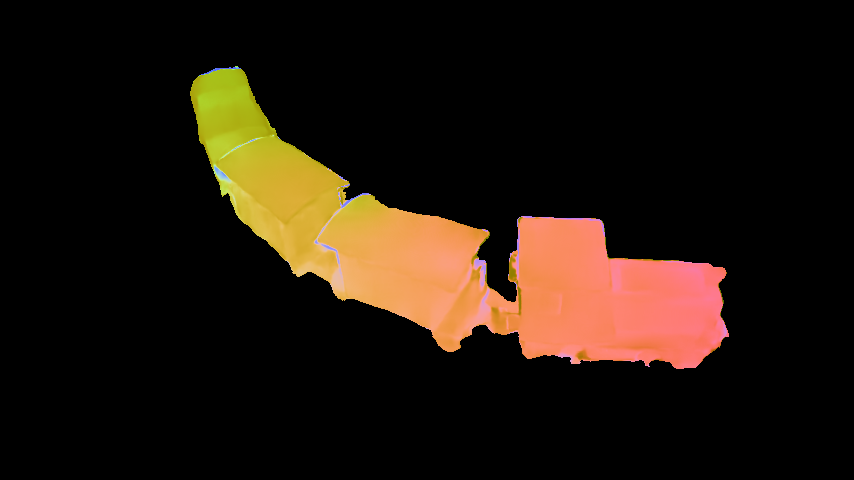

In [18]:
Image.fromarray( (velocity_fwd_vis * masks[..., None] * 255).byte()[0].numpy() )

torch.Size([78, 480, 854, 3])